##### DecisionTransformerは「過去の経験を振り返ってパターンを学習する」という教師あり学習のアプローチをとるため、以下の性質がある

- 「報酬を最大化するように試行錯誤する」強化学習とは異なり、「ある報酬を得るための行動パターンを予測する」という条件付きシーケンスモデリング
- オフライン学習
- エピソディックでありTD法とは合わない(TD法は試行錯誤の中で「どの状態が良いか」を動的に見積もるため、データが少ない状態からでも新しい戦略を見つけるのが得意)
- DecisionTransformerは、学習データに含まれていない「より良い行動」を自ら発見する能力（外挿）は弱い
- DecisionTransformerの使い所は、「成功したエピソード」が大量にあり、その時の状況と報酬の関係を模倣させたい場合や、長期的な依存関係(かなり前の行動が今の報酬に効いているなど)を捉える必要があるタスクに向いている

In [1]:
import collections
import copy
import itertools
import random

import matplotlib.pyplot as plt
import numpy as np
import pydantic
import torch
from tqdm.notebook import tqdm

random.seed(1234)
np.random.seed(1234)
torch.manual_seed(1234)
print("numpy: ", np.__version__)
print("pydantic", pydantic.__version__)
print("torch: ", torch.__version__)

numpy:  2.0.2
pydantic 2.12.3
torch:  2.10.0+cpu


### 環境(シミュレータ)

In [2]:
class PriceEnvironment():
    def __init__(self, max_inventory, max_step_count, price_min, price_max):
        self.max_inventory = max_inventory
        self.inventory = self.max_inventory
        self.max_step_count = max_step_count
        self.step_count = 0
        self.price_min = price_min
        self.price_max = price_max

    def step(self, continuous_action):
        price = self.price_min + (self.price_max - self.price_min) * ((continuous_action + 1) / 2)  # price_min～price_maxでの連続値 # continuous_actionはtanhの結果で-1～1の想定
        price = round(number=price,  # 1の桁を四捨五入して連続値のpriceを10刻みに量子化する
                      ndigits=-1)
        price = np.clip(a=price,  # 1の桁の四捨五入でprice_minを下回ったり、price_maxを上回ったりする事を考慮してnp.clipで範囲内の収める
                        a_min=self.price_min,
                        a_max=self.price_max)
        demand_expectation = int((self.price_max / price) * (self.inventory * 0.05))  # 「在庫の5%」×「重み」を「需要の期待値」とする # 「重み」は、最高価格に対する価格の割合の逆数(価格が高いと重みは小さい)とする
        demand = np.random.poisson(lam=demand_expectation,  # 「需要の期待値」を「ポアソン分布の期待値」として、ポアソン分布から「需要」を確率的に得る
                                   size=None)  # 引数sizeをNoneにする事でポアソン分布から1個だけの値を確率的に得る # sizeを100にすると100個の値を確率的に得る形になる
        saled_inventory = min(self.inventory, max(demand, 0))  # 「売れた在庫」は、「需要」と「在庫数」の小さい方の値とする # 「在庫数」以上の「需要」は売れないため
        reward = price * saled_inventory
        self.inventory = self.inventory - saled_inventory
        inventory_ratio = self.inventory / self.max_inventory
        self.step_count = self.step_count + 1
        step_ratio = (self.max_step_count - self.step_count) / self.max_step_count
        if self.inventory <= 0 or self.step_count >= self.max_step_count:
            done = True
        else:
            done = False
        next_state = np.array([inventory_ratio, step_ratio],
                              dtype=np.float32)
        return reward, next_state, done

    def reset(self):
        self.inventory = self.max_inventory
        self.step_count = 0
        initial_inventory_ratio = self.inventory / self.max_inventory
        initial_step_ratio = (self.max_step_count - self.step_count) / self.max_step_count
        initial_state = np.array([initial_inventory_ratio, initial_step_ratio],
                                 dtype=np.float32)
        done = False
        return initial_state, done

    def check_price_by_action(self, continuous_action):
        price = self.price_min + (self.price_max - self.price_min) * ((continuous_action + 1) / 2)
        price = round(number=price,
                      ndigits=-1)
        price = np.clip(a=price,
                        a_min=self.price_min,
                        a_max=self.price_max)
        return price

### Decision Transformer

In [3]:
class MyDecisionTransformer(torch.nn.Module):
    def __init__(self, state_dim, action_dim, embed_dim, num_transformer_layer, num_transformer_head, max_seq_size):
        super().__init__()
        # 状態、行動、目標報酬を埋め込みに変換する層
        self.embed_state_layer = torch.nn.Linear(in_features=state_dim,
                                                 out_features=embed_dim)
        self.embed_action_layer = torch.nn.Linear(in_features=action_dim,
                                                  out_features=embed_dim)
        self.embed_reward_to_go_layer = torch.nn.Linear(in_features=1,
                                                        out_features=embed_dim)
        # transformerでは定石となる位置情報を作成する層(torch.sinやcosでなくtorch.Embeddingで作成する)
        self.position_layer = torch.nn.Embedding(num_embeddings=max_seq_size,
                                                 embedding_dim=embed_dim)
        # transformer層
        self.transformer_layer = torch.nn.TransformerEncoder(encoder_layer=torch.nn.TransformerEncoderLayer(d_model=embed_dim,  # 入力と出力の次元はどちらもembed_dimになる
                                                                                                             nhead=num_transformer_head,
                                                                                                             dim_feedforward=embed_dim*4,
                                                                                                             batch_first=True),
                                                              num_layers=num_transformer_layer)
        # 出力層
        self.predict_action_layers = torch.nn.Sequential(
            torch.nn.Linear(in_features=embed_dim,
                            out_features=action_dim),
            torch.nn.Tanh()
        )

    def forward(self, state_tensor_data, action_tensor_data, reward_to_go_tensor_data, seq_tensor_data):
        batch_size = state_tensor_data.shape[0]
        seq_size = state_tensor_data.shape[1]
        # それぞれのデータを埋め込みに変換する
        out_embed_state_layer = self.embed_state_layer(state_tensor_data)
        out_embed_action_layer = self.embed_action_layer(action_tensor_data)
        out_embed_reward_to_go_layer = self.embed_reward_to_go_layer(reward_to_go_tensor_data)
        # 位置情報を作成する
        out_position_layer = self.position_layer(seq_tensor_data)
        # それぞれの埋め込みに位置情報を加算する
        embed_state = out_embed_state_layer + out_position_layer  # (batch, seq, embed_dim)
        embed_action = out_embed_action_layer + out_position_layer  # (batch, seq, embed_dim)
        embed_reward_to_go = out_embed_reward_to_go_layer + out_position_layer  # (batch, seq, embed_dim)
        # transformer層への入力データとして、R1 s1 a1 R2 s2 a2 R3,,,を行方向に並べた形にする
        transformer_input_temp = torch.stack(tensors=[embed_reward_to_go, embed_state, embed_action],  # (batch, seq, 3, embed_dim)
                                             dim=2)
        transformer_input = torch.reshape(input=transformer_input_temp,  # (batch, seq*3, embed_dim)
                                          shape=(batch_size, seq_size*3, -1))  # つまりは、行方向にR1 s1 a1 R2 s2 a2 R3,,,という形で並んでる
        # transformer層で学習時にカンニングを防ぐためのマスクを作成
        mask_size = seq_size * 3  # マスクはattentionの正方行列になるので、大きさはseq*3になる
        mask_for_transformer = torch.triu(input=torch.ones(size=(mask_size, mask_size)) == 1,  # == 1を入れる事でマスクをtrue/falseの形にする
                                          diagonal=1).to(DEVICE)
        # transformer層
        out_transformer_layers = self.transformer_layer(src=transformer_input,  # (batch, seq*3, embed_dim)
                                                        mask=mask_for_transformer)
        # 出力層で処理するにあたり、入力データはstate部分のtransformer結果を用いる
        # つまり、transformer結果の[:, 1, :]や[:, 4, :]になるので、[:, 1::3, :]で取得する
        predict_action_input = out_transformer_layers[:, 1::3, :]
        out_predict_action_layers = self.predict_action_layers(predict_action_input)
        return out_predict_action_layers

### 実データ収集(環境シミュレータから収集)

In [4]:
class EpisodeDatas(pydantic.BaseModel):
    model_config = pydantic.ConfigDict(arbitrary_types_allowed=True)
    state: np.ndarray
    action: np.ndarray
    reward_to_go: np.ndarray
    seq: np.ndarray

    def __len__(self):  # エピソード毎の時系列数を取得するため
        return len(self.state)

In [5]:
def collect_episode_datas(environment, num_episode):
    episode_datas_list = []
    for _ in range(num_episode):
        state_list = []
        action_list = []
        reward_list = []
        state, done = environment.reset()
        # 1エピソード分のデータを収集する
        while not done:
            action = np.random.uniform(low=-1,  # 一様分布で-1から
                                       high=1,  # 1までの値を
                                       size=1)  # 1つ取得するのでshapeは(1, )になる
            reward, next_state, done = environment.step(continuous_action=action[0])
            state_list.append(state)
            action_list.append(action)
            reward_list.append(reward)
            state = next_state
        # 収集した1エピソード分のデータを整える
        reward_reverse_array = np.flip(m=reward_list,  # 報酬リストを逆順にした形のarray
                                       axis=None)
        reward_cumsum_array = np.cumsum(a=reward_reverse_array,  # 逆順にした報酬リストの要素0から順に累積和を算出した形のarray
                                        axis=None)
        reward_to_go_array = np.flip(m=reward_cumsum_array,  # 再び逆順にすれば目的報酬の形のarrayになる
                                     axis=None)
        reward_to_go_array = reward_to_go_array.reshape((-1, 1)).astype(dtype=np.float32)  # 形状は(時系列数, 1)
        state_array = np.array(state_list,  # 形状は(時系列数, 2)
                               dtype=np.float32)
        action_array = np.array(action_list,  # 形状は(時系列数, 1)
                                dtype=np.float32)
        seq = len(state_list)  # そのエピソードでの時系列数は状態や行動のリストの要素数になるため
        seq_array = np.array(range(seq),  # 形状は(時系列数, )
                             dtype=np.int32)
        # 1エピソード分のデータをpydanticクラスで保存する
        episode_datas = EpisodeDatas(state=state_array,
                                     action=action_array,
                                     reward_to_go=reward_to_go_array,
                                     seq=seq_array)
        # リストの1要素として保存する
        episode_datas_list.append(episode_datas)
    return episode_datas_list

### 収集した実データの報酬和を把握

In [6]:
def visualize_sum_reward_per_episode(episode_datas_list):
    sum_reward_per_episode_list = []
    for episode_datas in episode_datas_list:
        sum_reward_per_episode = episode_datas.reward_to_go[0][0]  # 目的報酬の算出方法を踏まえると、1時系列目の値がそのエピソードでの報酬和になる
        sum_reward_per_episode_list.append(sum_reward_per_episode)
    print("最高値： ", max(sum_reward_per_episode_list))
    print("平均値： ", sum(sum_reward_per_episode_list) / len(sum_reward_per_episode_list))
    fig, (ax1) = plt.subplots(nrows=1,
                              ncols=1,
                              figsize=(16, 10))
    ax1.hist(x=sum_reward_per_episode_list,
             bins=20,  # 表示するビンの数 # ビンの数値幅ではない
             label="sum_reward_per_episode")
    ax1.legend(loc=0)
    ax1.set_title(label="figure: histgram sum reward per episode")
    ax1.set_xlabel(xlabel="sum reward")
    ax1.set_ylabel(ylabel="number")
    ax1.grid(True)
    plt.show()
    return None

### モデル入力用のデータセット作成

In [7]:
# 収集した実データを用いて、状態や行動や目的報酬のミニバッチデータセットを作成する
# 具体的には、エピソード毎に時系列数が異なる可能性があるので、パディングを行う等の前処理を行う形になる
def create_dataset_for_model(episode_datas_list, batch_size, max_seq_size):
    state_list = []
    action_list = []
    reward_to_go_list = []
    seq_list = []
    mask_list = []  # transformerでよく使われる「対象データは1、対象でないデータは0」のマスク # パディングの箇所をtransformerモデルへ示せる
    for _ in range(batch_size):
        episode_datas = random.choice(seq=episode_datas_list)
        # pydanticクラスで定義した__len__関数
        the_episode_seq_len = len(episode_datas)
        # エピソードから切り出す時系列のスタートの要素番号
        start_idx = random.randint(a=0,
                                   b=max(0,
                                         the_episode_seq_len - max_seq_size))
        # エピソードから切り出す時系列のゴールの要素番号
        goal_idx = start_idx + max_seq_size
        # 状態、行動、目的報酬、時系列番号のデータをmax_seq_sizeの分だけ切り出す
        # ※スライシングの場合はgoal_idxでout of rangeにならず切り出せる分だけ切り出す挙動になる
        sliced_state = episode_datas.state[start_idx:goal_idx, :]  # 形状は(切り出した要素数, 2)
        sliced_action = episode_datas.action[start_idx:goal_idx, :]  # 形状は(切り出した要素数, 1)
        sliced_reward_to_go = episode_datas.reward_to_go[start_idx:goal_idx, :]  # 形状は(切り出した要素数, 1)
        sliced_seq = episode_datas.seq[start_idx:goal_idx]  # 形状は(切り出した要素数, )
        # 切り出した要素数がmax_seq_size未満の場合はパディングする
        sliced_seq_len = sliced_seq.shape[0]  # 切り出した要素数
        mask = np.ones(shape=(sliced_seq_len, ),
                       dtype=np.int32)
        if sliced_seq_len < max_seq_size:  # パディングする
            padding_len = max_seq_size - sliced_seq_len
            padding_state = np.zeros(shape=(padding_len, sliced_state.shape[1]),
                                     dtype=np.float32)
            sliced_state = np.concatenate([sliced_state, padding_state],
                                          axis=0)
            padding_action = np.zeros(shape=(padding_len, sliced_action.shape[1]),
                                      dtype=np.float32)
            sliced_action = np.concatenate([sliced_action, padding_action],
                                           axis=0)
            padding_reward_to_go = np.zeros(shape=(padding_len, sliced_reward_to_go.shape[1]),
                                            dtype=np.float32)
            sliced_reward_to_go = np.concatenate([sliced_reward_to_go, padding_reward_to_go],
                                                 axis=0)
            padding_seq = np.zeros(shape=(padding_len, ),
                                   dtype=np.int32)
            sliced_seq = np.concatenate([sliced_seq, padding_seq],
                                        axis=0)
            padding_mask = np.zeros(shape=(padding_len),
                                    dtype=np.int32)
            mask = np.concatenate([mask, padding_mask],
                                  axis=0)
        # リストで繋げる
        state_list.append(sliced_state)
        action_list.append(sliced_action)
        reward_to_go_list.append(sliced_reward_to_go)
        seq_list.append(sliced_seq)
        mask_list.append(mask)
    # ミニバッチにする
    batch_state = np.stack(arrays=state_list,  # 形状は(batch, max_seq_size, 2)
                           axis=0)
    batch_action = np.stack(arrays=action_list,  # 形状は(batch, max_seq_size, 1)
                            axis=0)
    batch_reward_to_go = np.stack(arrays=reward_to_go_list,  # 形状は(batch, max_seq_size, 1)
                                  axis=0)
    batch_seq = np.stack(arrays=seq_list,  # 形状は(batch, max_seq_size)
                         axis=0)
    batch_mask = np.stack(arrays=mask_list,  # 形状は(batch, max_seq_size)
                          axis=0)
    return (batch_state, batch_action, batch_reward_to_go, batch_seq, batch_mask)

### モデル学習(Decision Transformer)

In [8]:
def train_decision_transformer(episode_datas_list, batch_size, max_seq_size, epochs, model, optimizer):
    loss_f = torch.nn.MSELoss(reduction="none")
    loss_list = []
    model.train()
    for epoch in tqdm(range(epochs)):
        batch_dataset_tuple = create_dataset_for_model(episode_datas_list=episode_datas_list,
                                                       batch_size=batch_size,
                                                       max_seq_size=max_seq_size)
        state = torch.as_tensor(data=batch_dataset_tuple[0],  # 形状は(batch, max_seq_size, 2)
                                dtype=torch.float32,
                                device=DEVICE)
        action = torch.as_tensor(data=batch_dataset_tuple[1],  # 形状は(batch, max_seq_size, 1)
                                 dtype=torch.float32,
                                 device=DEVICE)
        reward_to_go = torch.as_tensor(data=batch_dataset_tuple[2],  # 形状は(batch, max_seq_size, 1)
                                       dtype=torch.float32,
                                       device=DEVICE)
        seq = torch.as_tensor(data=batch_dataset_tuple[3],  # 形状は(batch, max_seq_size)
                              dtype=torch.int32,
                              device=DEVICE)
        mask = torch.as_tensor(data=batch_dataset_tuple[4],  # 形状は(batch, max_seq_size)
                               dtype=torch.int32,
                               device=DEVICE)
        predicted_action = model(state_tensor_data=state,  # 出力の形状は(batch, max_seq_size, 1)
                                 action_tensor_data=action,
                                 reward_to_go_tensor_data=reward_to_go,
                                 seq_tensor_data=seq)
        raw_loss = loss_f(input=predicted_action,  # 出力の形状は(バッチ数、max_seq_size, 1)
                          target=action)
        masked_loss = raw_loss * mask.unsqueeze(dim=-1)  # 出力の形状は(バッチ数、max_seq_size, 1)
        loss = masked_loss.sum() / mask.sum()  # 有効な要素数での平均になる # 出力はスカラー値
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_list.append(loss.item())
    return loss_list

### モデル推論(Decision Transformer)

In [9]:
def inference_decision_transformer(environment, model, max_seq_size, target_sum_reward):
    model.eval()
    state_list = []
    action_list = []
    reward_to_go_list = []
    seq_list = []
    state, done = environment.reset()
    state_list.append(state)
    action = random.uniform(a=-1, b=1)  # 1時系列目の行動はランダム取得とする
    action_list.append(action)
    reward_to_go_list.append(target_sum_reward)  # 1時系列目の目的報酬の値は、目指したい目標報酬の値になる
    seq = 0
    seq_list.append(seq)
    sum_reward = 0
    while not done:
        state_array = np.array(state_list[- max_seq_size:],
                               dtype=np.float32)
        action_array = np.array(action_list[- max_seq_size:],
                                dtype=np.float32)
        reward_to_go_array = np.array(reward_to_go_list[- max_seq_size:],
                                      dtype=np.float32)
        seq_array = np.array(seq_list[- max_seq_size:],
                             dtype=np.int32)
        # それぞれのarrayをtensorにしつつ、batchの次元の1を加えて適切な形状にする
        state_tensor = torch.as_tensor(data=state_array,  # 形状は(1, 時系列数, 2)
                                       dtype=torch.float32,
                                       device=DEVICE).unsqueeze(dim=0)
        action_tensor = torch.as_tensor(data=action_array,  # 形状は(1, 時系列数, 1)
                                        dtype=torch.float32,
                                        device=DEVICE).view((1, -1, 1))
        reward_to_go_tensor = torch.as_tensor(data=reward_to_go_array,  # 形状は(1, 時系列数, 1)
                                              dtype=torch.float32,
                                              device=DEVICE).view((1, -1, 1))
        seq_tensor = torch.as_tensor(data=seq_array,  # 形状は(1, 時系列数)
                                     dtype=torch.int32,
                                     device=DEVICE).unsqueeze(dim=0)
        # 学習済みDecision Transformerで行動を推論する
        with torch.no_grad():
            predicted_action_tensor = model(state_tensor_data=state_tensor,  # 形状は(1, 時系列数, 1)
                                            action_tensor_data=action_tensor,
                                            reward_to_go_tensor_data=reward_to_go_tensor,
                                            seq_tensor_data=seq_tensor)
            # 最新の時系列の行動を用いるので、時系列のインデックスは-1を指定する
            predicted_action = predicted_action_tensor[0, -1, 0].cpu().item()
        reward, next_state, done = env.step(continuous_action=predicted_action)
        state_list.append(next_state)
        action_list.append(predicted_action)
        reward_to_go = reward_to_go_list[-1] - reward  # 目的報酬は「最新の目的報酬 - 取得した報酬」になる
        reward_to_go_list.append(reward_to_go)
        seq = seq + 1
        seq_list.append(seq)
        sum_reward = sum_reward + reward
    return action_list, reward_to_go_list, sum_reward

### 学習

In [10]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
MAX_INVENTORY = 100
MAX_STEP_COUNT = 31
INITIAL_STATE = np.array([MAX_INVENTORY / MAX_INVENTORY,
                          MAX_STEP_COUNT / MAX_STEP_COUNT],  # 状態(観察)は[残り在庫の割合, 残りステップの割合]で表現する
                         dtype=np.float32)
PRICE_MIN = 100
PRICE_MAX = 180
# torch.nn.Embeddingの引数num_embeddingsは最大要素数というよりは最大要素番号の値になるため
# 自然言語処理で単語数は4096の時にtorch.nn.Embeddingで引数num_embeddingsは4096+1の4097で設定するのと同じ考え方
SEQ_LENGTH_FOR_MODEL = MAX_STEP_COUNT + 1

In [11]:
env = PriceEnvironment(max_inventory=MAX_INVENTORY,
                       max_step_count=MAX_STEP_COUNT,
                       price_min=PRICE_MIN,
                       price_max=PRICE_MAX)
my_model = MyDecisionTransformer(state_dim=2,
                                 action_dim=1,
                                 embed_dim=256,
                                 num_transformer_layer=5,
                                 num_transformer_head=8,
                                 max_seq_size=SEQ_LENGTH_FOR_MODEL).to(DEVICE)
my_optimizer = torch.optim.Adam(params=my_model.parameters(),
                                lr=0.001)

In [12]:
episode_datas_list = collect_episode_datas(environment=env,
                                           num_episode=100)
loss_list = train_decision_transformer(episode_datas_list=episode_datas_list,
                                       batch_size=10,
                                       max_seq_size=SEQ_LENGTH_FOR_MODEL,
                                       epochs=50,
                                       model=my_model,
                                       optimizer=my_optimizer)
result_dict_list = [{"name": "loss",
                     "epochs_list": range(len(loss_list)),
                     "values_list": loss_list}]

  0%|          | 0/50 [00:00<?, ?it/s]

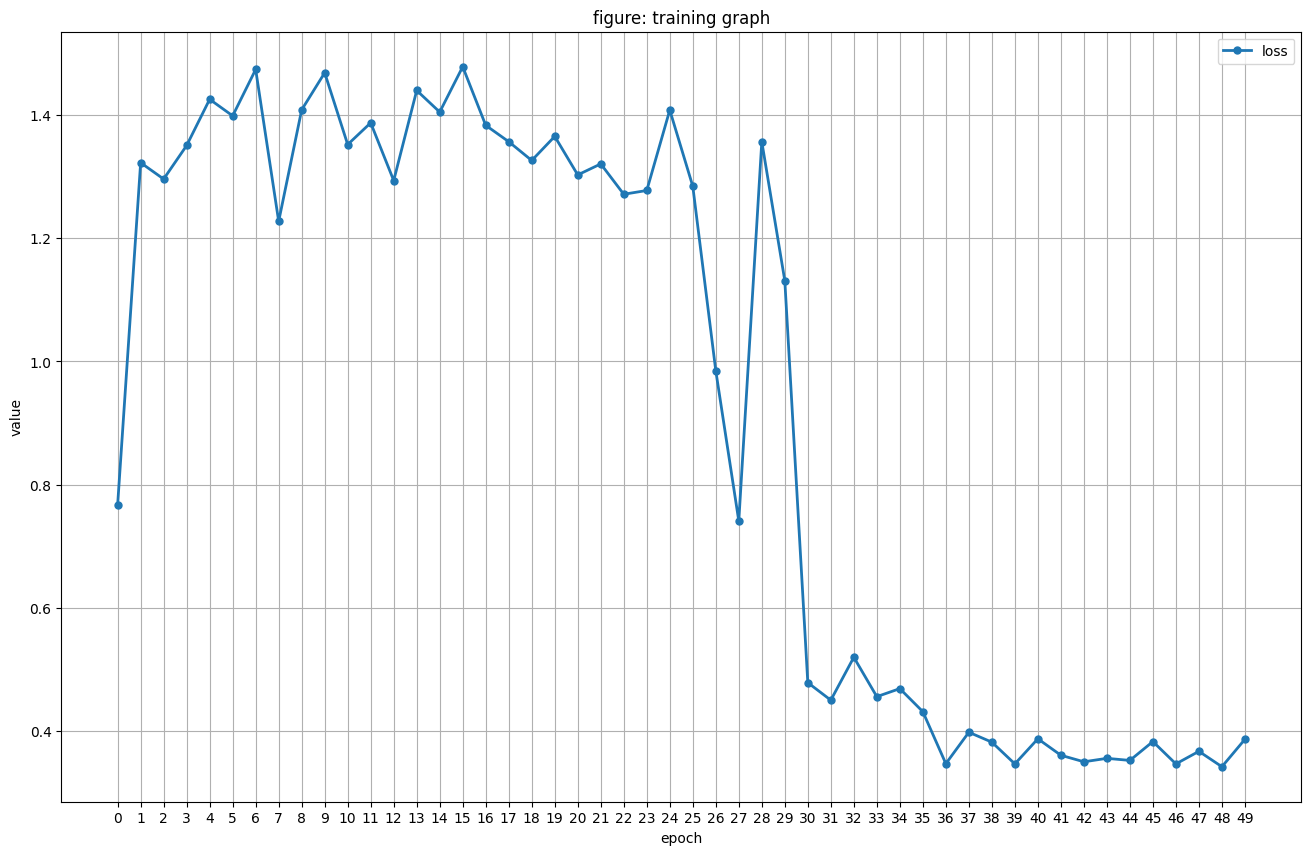

In [13]:
fig, (ax1) = plt.subplots(nrows=1,
                          ncols=1,
                          figsize=(16, 10))
for result_dict in result_dict_list:
    ax1.plot(result_dict["epochs_list"],
             result_dict["values_list"],
             label=result_dict["name"],
             marker="o",
             markersize=5,
             linestyle="solid",
             linewidth=2.0)
ax1.legend(loc=0)
ax1.set_title(label="figure: training graph")
ax1.set_xlabel(xlabel="epoch")
ax1.set_ylabel(ylabel="value")
ax1.set_xticks(ticks=result_dict_list[0]["epochs_list"])
ax1.grid(True)
plt.show()

### 推論

最高値：  12470.0
平均値：  11091.5


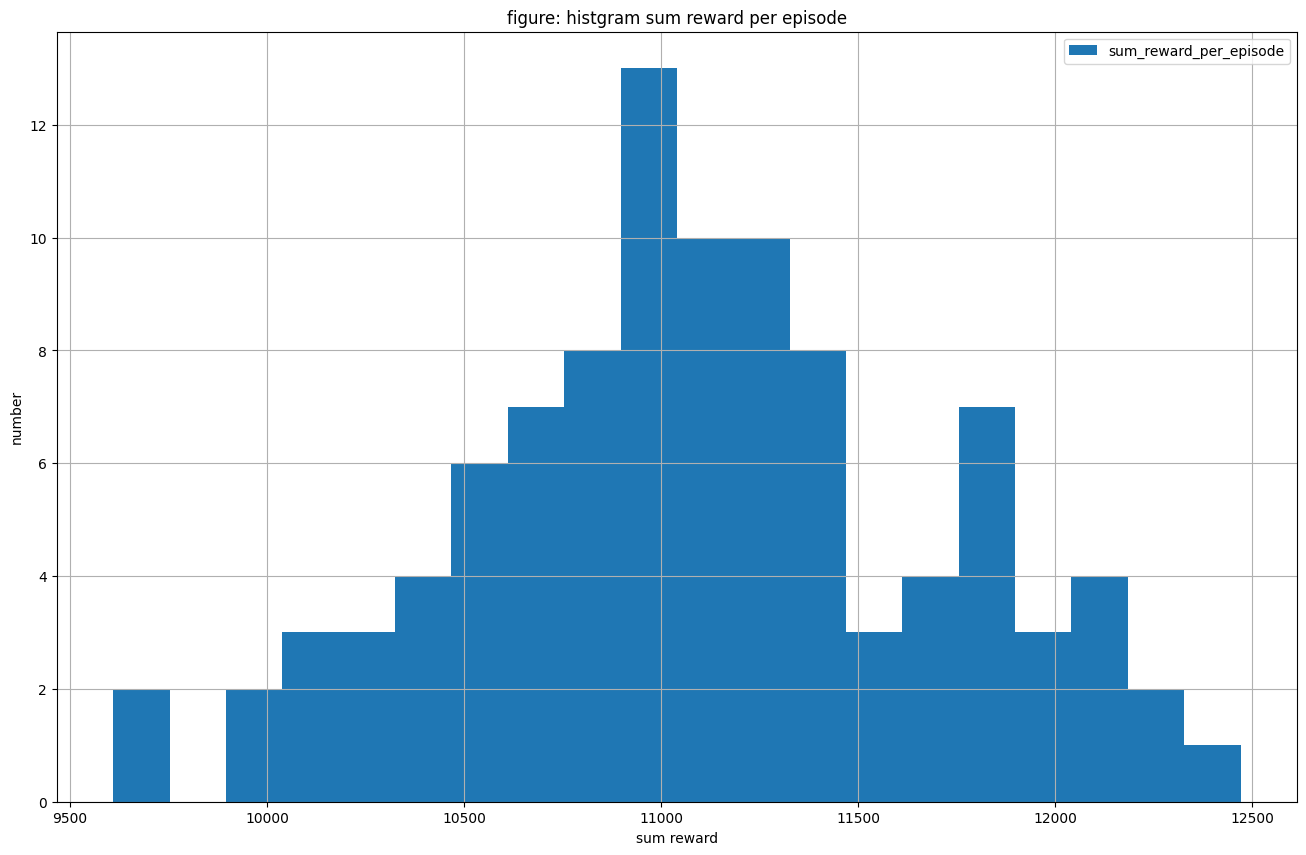

In [14]:
visualize_sum_reward_per_episode(episode_datas_list=episode_datas_list)

In [21]:
TARGET_SUM_REWARD = 12250
action_list, reward_to_go_list, sum_reward = inference_decision_transformer(environment=env,
                                                                            model=my_model,
                                                                            max_seq_size=SEQ_LENGTH_FOR_MODEL,
                                                                            target_sum_reward=TARGET_SUM_REWARD)
price_list = []
for action in action_list:
    price = env.check_price_by_action(continuous_action=action)
    price_list.append(price)

設定した目標報酬：  12250
推論による行動で得られた合計報酬：  11620.0


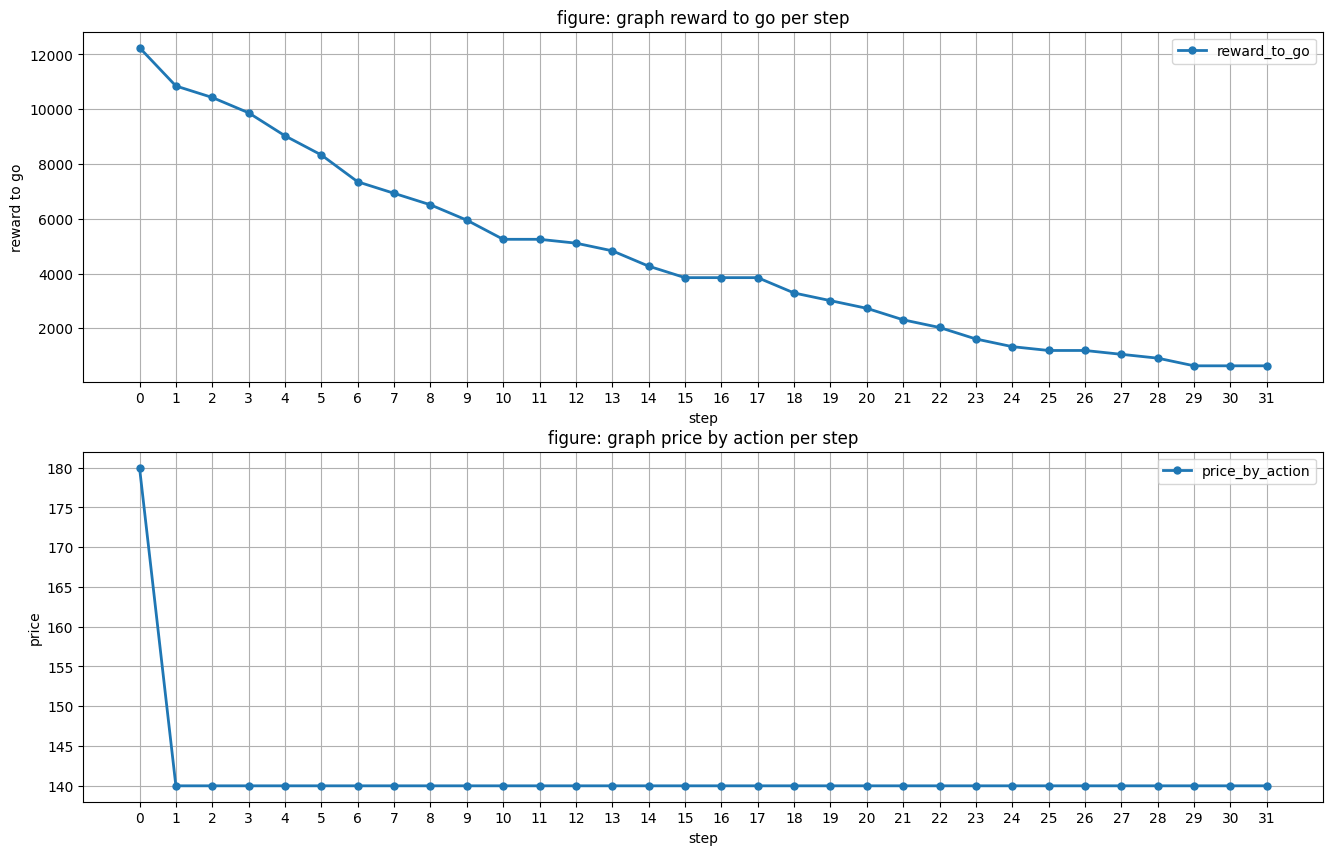

In [22]:
print("設定した目標報酬： ", TARGET_SUM_REWARD)
print("推論による行動で得られた合計報酬： ", sum_reward)
fig, (ax1, ax2) = plt.subplots(nrows=2,
                               ncols=1,
                               figsize=(16, 10))
ax1.plot(range(len(reward_to_go_list)),
         reward_to_go_list,
         label="reward_to_go",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2.0)
ax1.legend(loc=0)
ax1.set_title(label="figure: graph reward to go per step")
ax1.set_xlabel(xlabel="step")
ax1.set_ylabel(ylabel="reward to go")
ax1.set_xticks(ticks=range(len(reward_to_go_list)))
ax1.grid(True)
ax2.plot(range(len(price_list)),
         price_list,
         label="price_by_action",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2.0)
ax2.legend(loc=0)
ax2.set_title(label="figure: graph price by action per step")
ax2.set_xlabel(xlabel="step")
ax2.set_ylabel(ylabel="price")
ax2.set_xticks(ticks=range(len(price_list)))
ax2.grid(True)
plt.show()